## Functional and Noisy Signal Population

In [1]:
# All Imports here
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Apply clean visual stylings
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
# Runtime Configuration for visualizations
plt.rcParams['figure.dpi'] = 100
# reproducible stichastic generation through seed set
np.random.seed(seed=42)  # Set the seed for reproducibility

## 1. Trignometric Harmonic Signal + 

Harmonic signal generated successfully with gaussian noise.
Time Domain Array Length: 200
Pure signal range :[-3.00, 3.00] 
Noisy signal range :[-4.12, 3.88] 
Calculated Noise variance :0.3105


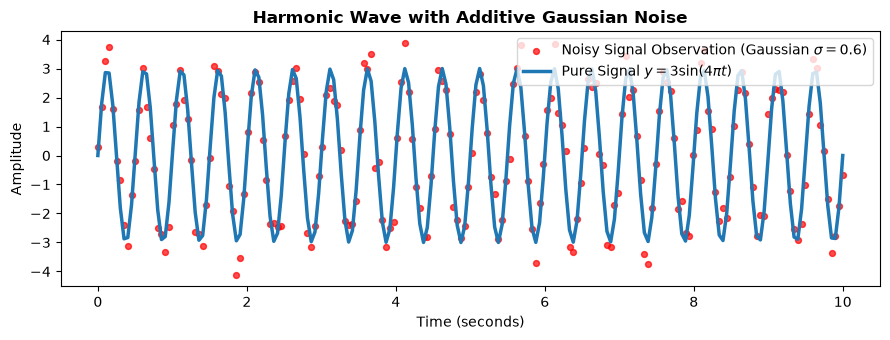

In [3]:
t = np.linspace(
    start = 0,  # Start of the time interval
    stop = 10,  # End of the time interval
    num = 200  # Number of evenly spaced points
    )  

f = 2.0 # Frequency of the signal
A = 3.0  # Amplitude of the signal

# Generate the clean sinusoidal signal
y_pure = A * np.sin(2 * np.pi * f * t)

# Add Gaussian noise to the clean signal (mean = 0, standard deviation = 0.6)
gaussian_noise = np.random.normal(
    loc=0.0, # Mean of the Gaussian noise
    scale=0.6,  # Standard deviation of the Gaussian noise
    size=len(t)
    )

# Generate the noisy signal by adding the Gaussian noise to the clean signal
y_noisy = y_pure + gaussian_noise

print("Harmonic signal generated successfully with gaussian noise.")
print("Time Domain Array Length:", len(t))
print(f"Pure signal range :[{y_pure.min():.2f}, {y_pure.max():.2f}] ")
print(f"Noisy signal range :[{y_noisy.min():.2f}, {y_noisy.max():.2f}] ")
print(f"Calculated Noise variance :{np.var(gaussian_noise):.4f}")

plt.figure(figsize=(9, 3.5))

# noisy observation (scatter plot)
plt.scatter(
    x=t,                # X-coordinate (time values)
    y=y_noisy,          # Y-coordinate (noisy signal values)
    color='red',        # Color of the scatter points
    s=18 ,              # Size of the scatter points (marker size)
    alpha=0.7,          # Transparency of the scatter points
    zorder=2 ,           # Drawing order of the scatter points
    label='Noisy Signal Observation (Gaussian $\\sigma=0.6$)', # legend label for the scatter plot
    )

# Pure Underlying Signal (Line Plot)
plt.plot(
    t,                                                     # X-axis sequence (time values)
    y_pure,                                                # Y-axis sequence (clean signal values)
    color='#1f77b4',                                       # Standard dark blue line color
    linewidth=2.5,                                         # Thickness of the plot line
    zorder=3,                                              # Drawn on top of scatter points
    label='Pure Signal $y = 3\\sin(4\\pi t)$'               # Legend label entry
)

plt.title(
    label='Harmonic Wave with Additive Gaussian Noise',    # Figure title text
    fontsize=12,                                           # Title font size in points
    fontweight='bold'                                      
)

plt.xlabel(xlabel='Time (seconds)')                       # X-axis label text
plt.ylabel(ylabel='Amplitude')                            # Y-axis label text
plt.legend(loc='upper right')                             # Corner anchor position for legend box
plt.tight_layout()                                        # Automatically adjusts subplots to fit figure area
plt.show()

## 2.Exponential Decay + Uniform Measurment Error

=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===
Initial Pure Value at t=0: 10.00
Final Pure Value at t=5: 0.1832
Uniform Error Bounds: [-0.4856, 0.4759]



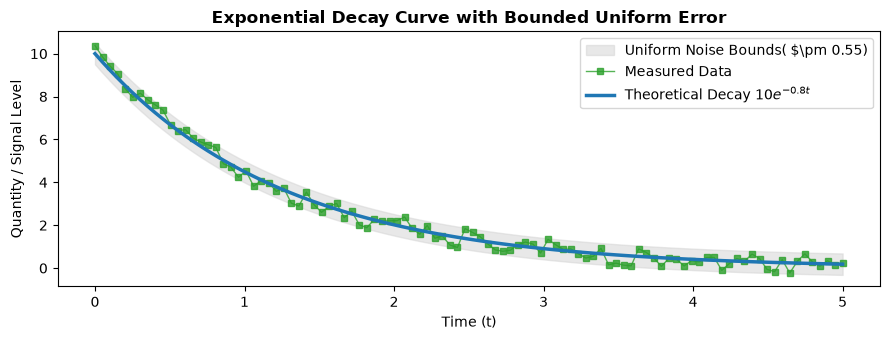

In [4]:
# Generate decay signal
t_decay = np.linspace(
    start=0.0,  # Start of time interval
    stop=5.0,   # End of time interval (5 seconds duration)
    num=100     # Total number of generated evaluation steps
)

N0 = 10.0  # Initial quantity at time t=0
decay_rate = 0.8 # decay constant lambda

# Generate the decay signal
y_decay_pure  = N0 * np.exp(-decay_rate * t_decay)

# generate bounded uniform measurement error in interval [-0.5, 0.5]
uniform_noise = np.random.uniform(
    low=-0.5,   # Lower bound of the uniform noise
    high=0.5,   # Upper bound of the uniform noise
    size=len(t_decay)  # Number of noise samples equal to the number of time points
)

# Generate the noisy decay signal by adding the uniform noise to the pure decay signal
y_decay_measured = y_decay_pure + uniform_noise


print("=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===")
print(f"Initial Pure Value at t=0: {y_decay_pure[0]:.2f}")
print(f"Final Pure Value at t=5: {y_decay_pure[-1]:.4f}")
print(f"Uniform Error Bounds: [{uniform_noise.min():.4f}, {uniform_noise.max():.4f}]\n")

# graphical representation of the decay signal
plt.figure(figsize=(9, 3.5))

# Bounded noise band visualization (shaded envelope)
plt.fill_between(
    x=t_decay,
    y1=y_decay_pure - 0.5,
    y2=y_decay_pure + 0.5,
    color='lightgray',  # Color of the shaded envelope
    alpha=0.5,          # Transparency of the shaded envelope
    label='Uniform Noise Bounds( $\\pm 0.55)'
)

# Plotting measured samples
plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_measured,                                       # Y-coordinates (measured noisy signal values)
    's-',                                                   # Marker & line style format (square markers with solid line)
    color='#2ca02c',                                        # Forest green line color
    linewidth=1,                                            # Thickness of connecting line
    markersize=4,                                           # Vertex square marker side dimension
    alpha=0.8,                                              # Line opacity
    label='Measured Data'                                   # Legend label entry
)

plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_pure,                                           # Y-coordinates (pure theoretical decay curve)
    color='#1f77b4',                                        # Dark blue color
    linewidth=2.5,                                          # Line thickness for ground truth curve
    label='Theoretical Decay $10 e^{-0.8t}$'                # Legend entry with LaTeX equation
)
plt.title(
    label='Exponential Decay Curve with Bounded Uniform Error',  # Plot title
    fontsize=12,                                                # Title text font size
    fontweight='bold'                                           # Bold title font weight
)
plt.xlabel(xlabel='Time (t)')                               # X-axis domain title
plt.ylabel(ylabel='Quantity / Signal Level')                # Y-axis range title
plt.legend(loc='upper right')                             # Position legend in upper right corner
plt.tight_layout()                                        # Optimize plot margin spacing
plt.show()

## Plynomial Functions + Spare Outliers (Salt and Peper / Impulse Noise)


=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===
Total data points: 120
Number of outliers: 9


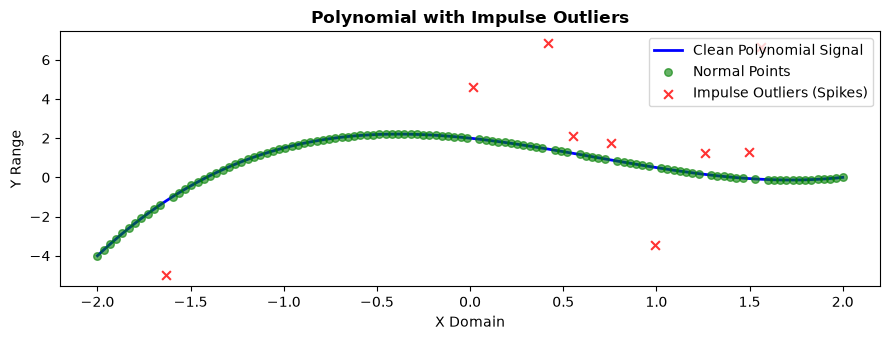

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create x values for polynomial
x_poly = np.linspace(
    start=-2.0,
    stop=2.0,
    num=120
)

# Clean polynomial signal
y_poly_clean = (
    0.5 * (x_poly**3)
    - (x_poly**2)
    - x_poly
    + 2
)

# Make a copy for adding outliers
y_poly_corrupted = y_poly_clean.copy()

# Calculate number of outliers
num_outliers = int(0.08 * len(x_poly))

# Randomly select indices for outliers
outliers_indices = np.random.choice(
    a=len(x_poly),
    size=num_outliers,
    replace=False
)

# Generate random spike magnitudes
spikes_magnitude = np.random.uniform(
    low=-4.0,
    high=8.0,
    size=num_outliers
)

# Add spikes to selected points
y_poly_corrupted[outliers_indices] += spikes_magnitude

print("=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===")
print(f"Total data points: {len(x_poly)}")
print(f"Number of outliers: {num_outliers}")


# -----------------------------
# Plot
# -----------------------------

plt.figure(figsize=(9, 3.5))

# Clean polynomial curve
plt.plot(
    x_poly,
    y_poly_clean,
    label='Clean Polynomial Signal',
    color='blue',
    linewidth=2,
    zorder=2
)

# -----------------------------
# Normal / uncorrupted points
# -----------------------------

normal_marks = np.ones_like(
    x_poly,
    dtype=bool
)

normal_marks[outliers_indices] = False

plt.scatter(
    x=x_poly[normal_marks],
    y=y_poly_corrupted[normal_marks],
    label='Normal Points',
    color='green',
    s=30,
    zorder=3,
    alpha=0.6
)

# -----------------------------
# Outlier / impulse points
# -----------------------------

plt.scatter(
    x=x_poly[outliers_indices],
    y=y_poly_corrupted[outliers_indices],
    label='Impulse Outliers (Spikes)',
    color='red',
    s=40,
    zorder=4,
    alpha=0.8,
    marker='x'
)

# -----------------------------
# Labels and title
# -----------------------------

plt.title(
    label='Polynomial with Impulse Outliers',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel(
    xlabel='X Domain'
)

plt.ylabel(
    ylabel='Y Range'
)

plt.legend(
    loc='upper right'
)

plt.tight_layout()

plt.show()

### Multi- Component Composite Signal  + Hetroscedastics Noise

In [ ]:
t_comp = np.linspace(
    start = 0.0,
    stop = 10.0,
    num = 300
)

trend = 0.5 * t_comp + 1.0

harmonics = 2.0 * np.sin(2 * np.pi * 0.5 * t_comp) + 0.8 * np.sin(2 * np.pi * 3.0 * t_comp)

S_pure = trend + harmonics

sigma_t = 0.1 + 0.1 * t_comp

hetro_noise = np.random.normal(
    loc = 0.0,
    scale = 1.0,
    size = len(t_comp),
) * sigma_t

y_component = S_pure + hetro_noise

print("=== 4. COMPOSITE SIGNAL + HETROSCEDASTIC NOISE ===")
print("Initial Noise Std dev (t = 0) : {sigma_t[0]:.4f}")
print("Final Noise Std dev (t = 0) : {sigma_t[0]:.4f}")

plt.figure(figsize=(9, 3.5))

plt.fill_between(
    x=t_comp,
    y1=S_pure - 2 * sigma_t,
    y2=S_pure + 2 * sigma_t,
    color='#9467bd',
    alpha=0.2,
    label='Expanding $2\\sigma(t)$ Confidence Band'
)

plt.plot(
    t_comp,
    y_component,
    color="#9467bd",
    linewidth=1.0,
    alpha=0.8,
    label='Pure Composite Signal'
)

plt.plot(
    t_comp,
    S_pure,
    color="#17becf",
    linewidth=2.5,
    label='Noisy Composite Signal'
)